This work develops a Gaussian Process Approximation (GPA) model to address the computational challenges of standard Gaussian Processes when the input size increases. The approach employs Random Fourier Features (RFF) to approximate the kernel function and reduce the matrix dimensionality, thereby improving computational efficiency. Using this simplified representation, the model optimizes the lengthscale, coefficient, and noise parameters via the SciPy optimizer. Based on the optimized values, the mean and standard deviation of the predictions are computed for the training, validation, and test datasets. Additionally, the model’s performance is evaluated using statistical metrics such as R², MSE, NLL, and miscalibration area.

In [2]:

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from datetime import datetime
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct

# ---------------- Load data ----------------
data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv") 

# Include multiple SampleIDs
filtered_data = data[data["SampleID"].isin(["(P07)", "(P14)", "(P11)"])].reset_index(drop=True)

feature_cols = ["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]
X = filtered_data[feature_cols].values
y = filtered_data["polarization"].values.reshape(-1, 1)

# ---------------- Train/Validation/Test Split ----------------
# Balanced representation of the target variable (y) distribution across train, validation, and test splits.
y_quantiles = pd.qcut(y.ravel(), q=10, labels=False)

X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X, y, filtered_data.index.values, test_size=0.1, random_state=42, stratify=y_quantiles
)

y_trainval_quantiles = pd.qcut(y_trainval.ravel(), q=10, labels=False)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval, y_trainval, idx_trainval, test_size=0.1111, random_state=42, stratify=y_trainval_quantiles
)  

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ---------------- Standardize (fit on training only) ----------------
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_val_scaled = scaler_y.transform(y_val).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

# ---------------- GPA-RFF Model ----------------
class GPA_RFF:
    def __init__(self, X, y, kernel="RBF", D=500, seed=42):
        self.X = X.astype(np.float64)
        self.y = y.astype(np.float64)
        self.kernel = kernel.upper()
        self.D = D
        np.random.seed(seed)

        self.b = 2 * np.pi * np.random.rand(D)
        self.W = None
        self.beta = None
        self.opt_params = None

        self.log_lengthscale = np.log(1.0)
        self.log_coeff = np.log(1.0)
        self.log_noise = np.log(1e-2)

    def _sample_W(self, lengthscale):
        d = self.X.shape[1]
        if self.kernel in ["RBF", "EQ"]:
            return np.random.normal(0, 1.0 / lengthscale, (d, self.D))
        elif self.kernel == "LAPLACE":
            return np.random.standard_cauchy((d, self.D)) / lengthscale
        elif self.kernel == "CAUCHY":
            return np.random.laplace(0, 1.0 / lengthscale, (d, self.D))
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def _phi(self, X, W, coeff):
        return np.sqrt(2/self.D) * np.cos(X @ W + self.b) * coeff # RFF transformation

    def neg_log_likelihood(self, params):
        lengthscale, coeff, noise = np.exp(params)

        # Clamp
        lengthscale = np.clip(lengthscale, 1e-2, 1e5)
        coeff      = np.clip(coeff, 1e-6, 1e5)
        noise      = np.clip(noise, 1e-4, 10.0)

        # Sample random features
        if self.W is None:
            self.W = self._sample_W(lengthscale)

        Phi = self._phi(self.X, self.W, coeff)  # n × D
        n, D = Phi.shape

        # Compute A = Phi^T Phi + noise^2 I
        A = Phi.T @ Phi + (noise**2) * np.eye(D)

        # Cholesky solve for log|A|
        try:
            L = np.linalg.cholesky(A)
        except:
            return 1e10

        # Compute alpha = A^{-1} Phi^T y  (in dual form)
        alpha = np.linalg.solve(A, Phi.T @ self.y)

        # Compute GP terms using Woodbury identity
        # y^T K^{-1} y = 1/noise^2 * ( y^T y - y^T Phi alpha )
        yt_y = np.dot(self.y, self.y)
        yt_Phi_alpha = np.dot(self.y, Phi @ alpha)

        quad_term = (yt_y - yt_Phi_alpha) / (noise**2)

        # log|K| = n*log(noise^2) + log|A|
        logdet_K = n * np.log(noise**2) + 2.0 * np.sum(np.log(np.diag(L)))

        # Final GP marginal likelihood
        nll = 0.5 * quad_term + 0.5 * logdet_K + 0.5 * n * np.log(2*np.pi)
        return nll
    
    def fit(self, method="L-BFGS-B"):
        init = [self.log_lengthscale, self.log_coeff, self.log_noise]
        # Initial boundary
        bounds = [
            (np.log(1e-2), np.log(1e5)),
            (np.log(1e-6), np.log(1e5)),
            (np.log(1e-3), np.log(10.0)),
        ]
        res = minimize(self.neg_log_likelihood, init, method=method, bounds=bounds) # Scipy minimizer
        self.opt_params = np.exp(res.x)

        lengthscale, coeff, noise = self.opt_params
        self.W = self._sample_W(lengthscale)
        phi = self._phi(self.X, self.W, coeff)
        K_ridge = phi.T @ phi + (noise**2) * np.eye(self.D)
        self.beta = np.linalg.solve(K_ridge, phi.T @ self.y)
        return res

    def predict(self, X_new, return_std=True):
        lengthscale, coeff, noise = self.opt_params
        phi_new = self._phi(X_new, self.W, coeff)
        y_pred = phi_new @ self.beta # Mean
        y_pred = y_pred.ravel() 

        # Training feature matrix
        phi_train = self._phi(self.X, self.W, coeff)
        
        # Sigma_t = Φ^T Φ + σ^2 I
        Sigma_t = phi_train.T @ phi_train + (noise**2) * np.eye(self.D)
        
        # Solve Sigma_t * v = phi_new^T
        v = np.linalg.solve(Sigma_t, phi_new.T)
        
        # Predictive variance: ˆσ^2_t(x) = σ^2 φ(x)^T Σ_t^{-1} φ(x)
        y_var = noise**2 * np.sum(phi_new * v.T, axis=1)
        y_std = np.sqrt(np.maximum(y_var, 1e-12))
        return y_pred, y_std.ravel()



# ---------------- Run experiments ----------------
os.makedirs("Results_GPA_D2048", exist_ok=True)
summary_path = "Results_GPA_D2048/gpa_rff_summary.csv"

# Initialize metrics summary file
summary_cols = ["Kernel", "Optimizer", "Dataset", "MSE", "R2", "NLL", "Miscal_Area"]
if not os.path.exists(summary_path):
    pd.DataFrame(columns=summary_cols).to_csv(summary_path, index=False)

kernels = ["RBF", "LAPLACE", "CAUCHY"]
methods = ["Nelder-Mead", "L-BFGS-B"]

for kernel in kernels:
    print("="*70)
    print(f"Kernel: {kernel}")
    for method in methods:
        print(f"\nOptimizer: {method}")

        gp = GPA_RFF(X_train_scaled, y_train_scaled, kernel=kernel, D=2048)
        try:
            res = gp.fit(method=method)
            print(f"Optimized params [lengthscale, coeff, noise]: {gp.opt_params}")

            coverage_levels = np.linspace(0, 1, 100)
            # predict for all data separately (train, val and test)

            datasets = [
                ("train", X_train_scaled, y_train, idx_train),
                ("val", X_val_scaled, y_val, idx_val),
                ("test", X_test_scaled, y_test, idx_test)
            ]

            for name, Xs, Ys, idxs in datasets:
                # Predict
                y_pred, y_std = gp.predict(Xs)
                y_orig = Ys.ravel()
                # Back to original labels
                y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1,1)).ravel()
                y_std_orig = y_std * scaler_y.scale_[0]

                # Reconstruct original features 
                df_features = pd.DataFrame(
                    scaler_X.inverse_transform(Xs), 
                    columns=feature_cols
                )
                df_features["start_time"] = filtered_data.loc[idxs, "start_time"].values
                df_features["end_time"] = filtered_data.loc[idxs, "end_time"].values

                df = pd.DataFrame({
                    "SampleID": filtered_data.loc[idxs, "SampleID"].values,
                    **df_features,
                    "y_true": y_orig,
                    "y_pred": y_pred_orig,
                    "y_std": y_std_orig
                })

                # Save predictions CSV
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"Results_GPA_D2048/gpa_rff_{kernel}_{method}_{name}_{timestamp}.csv"
                df.to_csv(filename, index=False)

                # ---- Metrics ----
                mse = mean_squared_error(y_orig, y_pred_orig)
                r2 = r2_score(y_orig, y_pred_orig)
                nll = 0.5*np.sum((y_orig - y_pred_orig)**2)/(gp.opt_params[2]**2) + 0.5*len(y_orig)*np.log(2*np.pi*gp.opt_params[2]**2)
                ma = uct.metrics_calibration.miscalibration_area(y_pred=y_pred_orig, y_std=y_std_orig, y_true=y_orig, num_bins=100, vectorized=False,prop_type='interval')

                print(f"{name.capitalize()} MSE: {mse:.5f}, R²: {r2:.5f}, NLL: {nll:.5f}, Miscal Area: {ma:.5f}")

                # ---- Save metrics to summary CSV ----
                new_row = pd.DataFrame([[kernel, method, name, mse, r2, nll, ma]], columns=summary_cols)
                new_row.to_csv(summary_path, mode='a', header=False, index=False)

        except Exception as e:
            print(f" Error with {kernel} + {method}: {e}")



Train: 4493, Val: 562, Test: 562
Kernel: RBF

Optimizer: Nelder-Mead
Optimized params [lengthscale, coeff, noise]: [1.00000000e-02 2.42191232e+02 9.17841654e-02]
Train MSE: 0.00147, R²: 0.70481, NLL: -6210.61108, Miscal Area: 0.41181
Val MSE: 0.00882, R²: -0.81868, NLL: -531.62873, Miscal Area: 0.43571
Test MSE: 0.00821, R²: -0.69110, NLL: -552.09444, Miscal Area: 0.43855

Optimizer: L-BFGS-B
Optimized params [lengthscale, coeff, noise]: [1.00000000e+00 2.50239004e+02 9.13355953e-02]
Train MSE: 0.00006, R²: 0.98818, NLL: -6608.09939, Miscal Area: 0.25041
Val MSE: 0.00013, R²: 0.97408, NLL: -824.30942, Miscal Area: 0.25964
Test MSE: 0.00038, R²: 0.92139, NLL: -815.69559, Miscal Area: 0.28919
Kernel: LAPLACE

Optimizer: Nelder-Mead
Optimized params [lengthscale, coeff, noise]: [1.00048569 1.00120877 0.06276426]
Train MSE: 0.00003, R²: 0.99483, NLL: -8294.84971, Miscal Area: 0.12905
Val MSE: 0.00005, R²: 0.98930, NLL: -1035.68011, Miscal Area: 0.16709
Test MSE: 0.00004, R²: 0.99211, NLL: 

Analysis of the performance of the test output (Laplace + Nelder-Mead) 

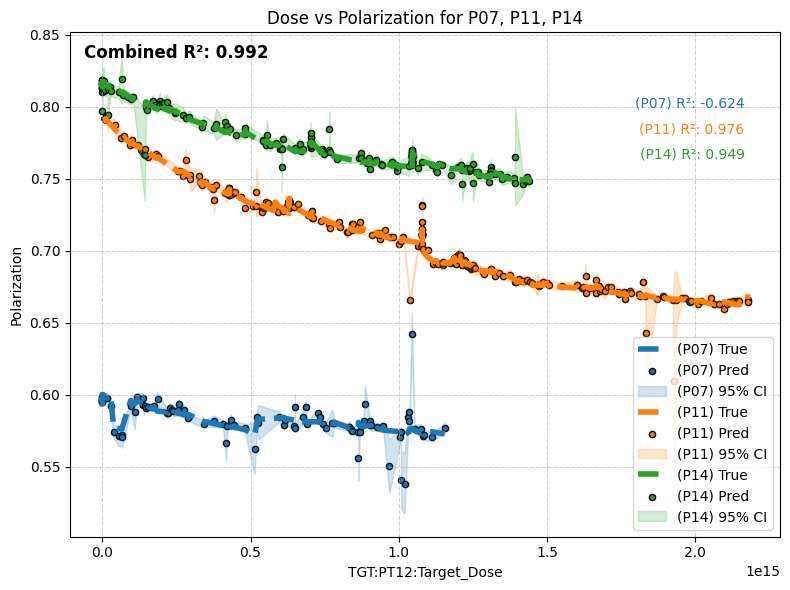

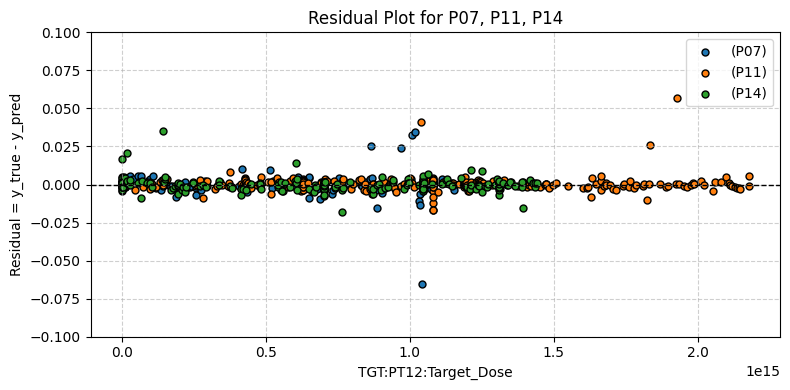

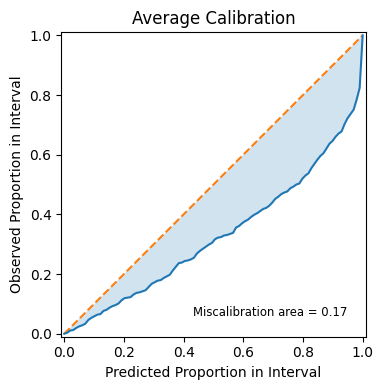

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct

# -------------------------------
# 1. Load and preprocess data
# -------------------------------
file_path = '/Users/monibor/Desktop/AIOP Target Optimization/untitled folder/GP/Generalized model/Results_GPA_D2048/gpa_rff_LAPLACE_Nelder-Mead_test_20251113_182803.csv'
df_all = pd.read_csv(file_path)
df_all["start_time"] = pd.to_datetime(df_all["start_time"], errors="coerce")

# Separate and sort by SampleID
sample_dfs = {sid: df_sample.sort_values(by="start_time").reset_index(drop=True)
              for sid, df_sample in df_all.groupby("SampleID")}

# Choose samples and assign colors
samples_to_plot = ["(P07)", "(P11)", "(P14)"]
colors = ["tab:blue", "tab:orange", "tab:green"]

# -------------------------------
# 2. Dose vs Polarization Plot
# -------------------------------
plt.figure(figsize=(8,6))
r2_values = {}

for sample_id, color in zip(samples_to_plot, colors):
    df = sample_dfs[sample_id].sort_values("TGT:PT12:Target_Dose")
    
    # Compute R²
    r2_values[sample_id] = r2_score(df["y_true"], df["y_pred"])
    
    # Plot true values
    plt.plot(df["TGT:PT12:Target_Dose"], df["y_true"], '--', linewidth=4, color=color, label=f"{sample_id} True")
    
    # Plot predicted values
    plt.scatter(df["TGT:PT12:Target_Dose"], df["y_pred"], color=color, edgecolor='k', s=20, marker="o", label=f"{sample_id} Pred")
    
    # Plot 95% confidence interval
    plt.fill_between(df["TGT:PT12:Target_Dose"],
                     df["y_pred"] - 1.96*df["y_std"],
                     df["y_pred"] + 1.96*df["y_std"],
                     color=color, alpha=0.2, label=f"{sample_id} 95% CI")

# Combined R²
combined_df = df_all[df_all["SampleID"].isin(samples_to_plot)]
combined_r2 = r2_score(combined_df["y_true"], combined_df["y_pred"])

plt.xlabel("TGT:PT12:Target_Dose")
plt.ylabel("Polarization")
plt.title("Dose vs Polarization for P07, P11, P14")
plt.grid(True, linestyle="--", alpha=0.6)
# plt.ylim(0.2, 1.2)
plt.legend(loc="lower right")

# Add R² values
for i, sample_id in enumerate(samples_to_plot):
    plt.text(0.95, 0.85 - i*0.05, f"{sample_id} R²: {r2_values[sample_id]:.3f}",
             transform=plt.gca().transAxes, ha='right', fontsize=10, color=colors[i])
plt.text(0.02, 0.95, f"Combined R²: {combined_r2:.3f}", transform=plt.gca().transAxes,
         ha='left', fontsize=12, fontweight='bold', color='black')
plt.tight_layout()
plt.show()

# -------------------------------
# 3. Residual Plot
# -------------------------------
plt.figure(figsize=(8,4))
for sample_id, color in zip(samples_to_plot, colors):
    df = sample_dfs[sample_id].sort_values("TGT:PT12:Target_Dose")
    residuals = df["y_true"] - df["y_pred"]
    plt.scatter(df["TGT:PT12:Target_Dose"], residuals, color=color, edgecolor='k', s=25, label=sample_id)

plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.xlabel("TGT:PT12:Target_Dose")
plt.ylabel("Residual = y_true - y_pred")
plt.title("Residual Plot for P07, P11, P14")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.ylim(-0.1, 0.1)
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Average Calibration Plot (Uncertainty Toolbox)
# -------------------------------
# Use last sample's df or merge all if desired
df = combined_df

fig, ax = plt.subplots(figsize=(4,4))
uct.viz.plot_calibration(y_true=df["y_true"].values,
                         y_pred=df["y_pred"].values,
                         y_std=df["y_std"].values,
                         ax=ax,
                         prop_type='interval')
plt.title("Average Calibration")
plt.tight_layout()
plt.show()


σ(GPA-RFF)/σ(GP) plot for verson of GPA for fixed hyperparameters

In [4]:

# Exact GP: https://random-walks.org/book/papers/rff/rff.html
def covariance(x1, x2, kernel, lengthscale, coefficient, noise=None):
    
    diff = x1[:, None, :] - x2[None, :, :]
    
    if kernel == 'eq':
        l2 = np.sum((diff / lengthscale) ** 2, axis=2)
        cov = coefficient ** 2 * np.exp(-0.5 * l2)
        
    elif kernel == 'laplace':
        l1 = np.sum(np.abs(diff / lengthscale), axis=2)
        cov = coefficient ** 2 * np.exp(-0.5 * l1)
        
    elif kernel == 'cauchy':
        l2 = np.sum((diff / lengthscale) ** 2, axis=2)
        cov = coefficient ** 2 / (1 + l2)
        
    if noise is not None:
        cov = cov + noise ** 2 * np.eye(cov.shape[0])
    
    return cov


def exact_gp_posterior(x_data, y_data, x_pred, kernel, lengthscale, coefficient, noise):
    
    Kdd = covariance(x_data, x_data, kernel, lengthscale, coefficient, noise)
    Kpd = covariance(x_pred, x_data, kernel, lengthscale, coefficient, None)
    Kpp = covariance(x_pred, x_pred, kernel, lengthscale, coefficient, None)
    
    mean = Kpd @ np.linalg.solve(Kdd, y_data[:, 0])
    var = np.diag(Kpp - Kpd @ np.linalg.solve(Kdd, Kpd.T))
    std = np.sqrt(var)
    
    return mean, std

In [5]:
# GPA: https://random-walks.org/book/papers/rff/rff.html
def sample_rff(
    x,
    kernel,
    lengthscale,
    coefficient,
    num_functions,
    num_features,
):
    
    # Dimension of data space
    x_dim = x.shape[-1]
    omega_shape = (num_functions, num_features, x_dim)
    
    # Handle each of three possible kernels separately
    if kernel == 'eq':
        omega = np.random.normal(size=omega_shape)
        
    elif kernel == 'laplace':
        omega =  np.random.standard_cauchy(size=omega_shape)
        
    elif kernel == 'cauchy':
        omega = np.random.laplace(size=omega_shape)
        
    # Scale omegas by lengthscale
    omega = omega / lengthscale
    
    weights = np.random.normal(
        loc=0.,
        scale=1.,
        size=(num_functions, num_features),
    )
    
    phi = np.random.uniform(
        low=0.,
        high=(2 * np.pi),
        size=(num_functions, num_features, 1),
    )
    
    features = np.cos(np.einsum('sfd, nd -> sfn', omega, x) + phi)
    features = (2 / num_features) ** 0.5 * features * coefficient
    
    functions = np.einsum('sf, sfn -> sn', weights, features)
    
    return functions, features

def rff_posterior(
    x_data,
    y_data,
    x_pred,
    kernel,
    lengthscale,
    coefficient,
    num_features,
    noise,
):
    
    num_data = x_data.shape[0]
    x_full = np.concatenate([x_pred, x_data])
    
    _, features = sample_rff(
        x=x_full, 
        kernel=kernel, 
        lengthscale=lengthscale, 
        coefficient=coefficient, 
        num_functions=1, 
        num_features=num_features,
    )
    features = features[0]
    
    features_pred = features[:, :-num_data]
    features_data = features[:, -num_data:]
    
    iS = np.eye(features_data.shape[0]) + \
        features_data @ features_data.T * noise ** -2

    mean_pred = noise ** -2 * \
        features_pred.T @ np.linalg.solve(iS, features_data @ y_data)[:, 0]
    
    var_pred = np.einsum(
        'fn, fn -> n',
        features_pred,
        np.linalg.solve(iS, features_pred),
    )
    var_std = np.sqrt(var_pred)
    return mean_pred, var_std

In [7]:
# GPA-RFF Model (Monibor implementation)
# https://gaussianprocess.org/gpml/chapters/RW.pdf
# https://papers.nips.cc/paper_files/paper/2007/file/013a006f03dbc5392effeb8f18fda755-Paper.pdf
# https://papers.nips.cc/paper_files/paper/2020/file/6dfe08eda761bd321f8a9b239f6f4ec3-Supplemental.pdf
class GPA_RFF:
    def __init__(self, X, y, kernel="RBF", D=500, seed=42, lengthscale=1, coeff=1, noise=0.01):
        self.X = X.astype(np.float64)
        self.y = y.astype(np.float64)
        self.kernel = kernel.upper()
        self.D = D
        np.random.seed(seed)

        self.b = 2 * np.pi * np.random.rand(D)
        self.W = None
        self.beta = None
        self.opt_params = None

        self.lengthscale = lengthscale
        self.coeff = coeff
        self.noise = noise

    def _sample_W(self, lengthscale):
        d = self.X.shape[1]
        if self.kernel in ["RBF", "EQ"]:
            return np.random.normal(0, 1.0 / lengthscale, (d, self.D))
        elif self.kernel == "LAPLACE":
            return np.random.standard_cauchy((d, self.D)) / lengthscale
        elif self.kernel == "CAUCHY":
            return np.random.laplace(0, 1.0 / lengthscale, (d, self.D))
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def _phi(self, X, W, coeff):
        # return np.sqrt(2/self.D) * np.cos(X @ W + self.b) * np.sqrt(coeff) # RFF transformation
        return np.sqrt(2 * (coeff**2) / self.D) * np.cos(X @ W + self.b)

    def fit(self):        
        self.W = self._sample_W(self.lengthscale)
        phi = self._phi(self.X, self.W, self.coeff)
        K_ridge = phi.T @ phi + (self.noise**2) * np.eye(self.D)
        self.beta = np.linalg.solve(K_ridge, phi.T @ self.y)
        return self

    def predict(self, X_new):        
        phi_new = self._phi(X_new, self.W, self.coeff)
        y_pred = phi_new @ self.beta # Mean
        y_pred = y_pred.ravel() 
        # Training feature matrix
        phi_train = self._phi(self.X, self.W, self.coeff)        
        # Sigma_t = Φ^T Φ + σ^2 I
        Sigma_t = phi_train.T @ phi_train + (self.noise**2) * np.eye(self.D)        
        # Solve Sigma_t * v = phi_new^T
        v = np.linalg.solve(Sigma_t, phi_new.T)        
        # Predictive variance: ˆσ^2_t(x) = σ^2 φ(x)^T Σ_t^{-1} φ(x)
        y_var = self.noise**2 * np.sum(phi_new * v.T, axis=1)
        y_std = np.sqrt(np.maximum(y_var, 1e-12))    
        return y_pred, y_std.ravel()

In [8]:
import os
import numpy as np

import pandas as pd
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from datetime import datetime
import uncertainty_toolbox as uct
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
# ---------------- Main ----------------
data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
filtered_data = data[data["SampleID"].isin(["(P07)", "(P14)", "(P11)"])].reset_index(drop=True)
feature_cols = ["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]
X = filtered_data[feature_cols].values
y = filtered_data["polarization"].values.reshape(-1,1)

# Train/test split (same as RFF)
y_quantiles = pd.qcut(y.ravel(), q=10, labels=False)
X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X, y, filtered_data.index.values, test_size=0.1, random_state=42, stratify=y_quantiles
)
y_trainval_quantiles = pd.qcut(y_trainval.ravel(), q=10, labels=False)
X_train_full, X_val, y_train_full, y_val, idx_train_full, idx_val = train_test_split(
    X_trainval, y_trainval, idx_trainval,
    test_size=0.1111, random_state=42, stratify=y_trainval_quantiles
    
)

# ---------------- Standardize (fit on training only) ----------------
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_full)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_full).ravel()
y_val_scaled = scaler_y.transform(y_val).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

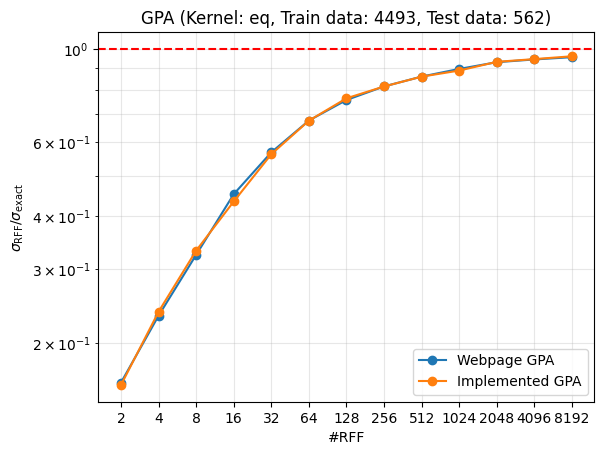

In [9]:
lengthscale = 1
coeff = 1
noise = 0.03
kernel = 'eq'
num_rff = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048,4096, 8192]

sigma_ratio_1 = {}
sigma_ratio_2 = {}
exact_mean, exact_std = exact_gp_posterior(x_data=X_train_scaled, y_data=y_train_full, x_pred=X_test_scaled, kernel=kernel, lengthscale=lengthscale, coefficient=coeff, noise=noise)
for rff in num_rff:
    # Use Webpage GPA
    approx_mean_1, approx_std_1 = rff_posterior(x_data=X_train_scaled, y_data=y_train_full, x_pred=X_test_scaled, kernel=kernel, lengthscale=lengthscale, coefficient=coeff, num_features=rff, noise=noise)
    sigma_ratio_1[rff] = np.mean(approx_std_1/exact_std)

    # Use Mobibor's GPA
    gpa = GPA_RFF(X_train_scaled, y_train_full, kernel=kernel, D=rff, lengthscale=lengthscale, coeff=coeff, noise=noise)
    gpa.fit()    
    approx_mean_2, approx_std_2 = gpa.predict(X_test_scaled)
    sigma_ratio_2[rff] = np.mean(approx_std_2/exact_std)

xs = np.array(sorted(sigma_ratio_1.keys()))
ys_1 = np.array([sigma_ratio_1[k] for k in xs])
ys_2 = np.array([sigma_ratio_2[k] for k in xs])

pos = np.arange(len(xs))
plt.figure()
plt.plot(pos, ys_1, marker='o', label='Webpage GPA')
plt.plot(pos, ys_2, marker='o', label='Implemented GPA')
plt.axhline(1.0, linestyle='--', color='r')
plt.xlabel("#RFF")
plt.ylabel(r"$\sigma_{\mathrm{RFF}} / \sigma_{\mathrm{exact}}$")
plt.yscale('log')
plt.xticks(pos, xs)
plt.title(f"GPA (Kernel: {kernel}, Train data: {X_train_scaled .shape[0]}, Test data: {X_test_scaled.shape[0]})")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()